# EDA для курсовой работы

Проверяются данные по химическим соединениям. Целевые показатели: `IC50, mM`, `CC50, mM`, `SI`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path('data/raw/coursework_data.xlsx')
ATTACHMENTS_DIR = Path('attachments')
ATTACHMENTS_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 30)

## Загрузка данных

Файл данных не хранится в репозитории. Перед запуском он должен лежать по пути `data/raw/coursework_data.xlsx`.

In [2]:
data = pd.read_excel(DATA_PATH)
data.shape

(1001, 214)

In [3]:
data.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,340.300,384.350449,158,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,340.300,388.381750,162,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,388.344,446.458903,186,0,...,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,352.311,398.366099,164,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,424.377,466.334799,184,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Общая структура

Проверяются типы колонок, дубликаты и пропуски.

In [4]:
target_columns = ['IC50, mM', 'CC50, mM', 'SI']
index_columns = ['Unnamed: 0']
feature_columns = [column for column in data.columns if column not in target_columns + index_columns]

summary = pd.DataFrame({
    'rows': [data.shape[0]],
    'columns': [data.shape[1]],
    'features': [len(feature_columns)],
    'duplicates': [int(data.duplicated().sum())],
    'rows_with_missing': [int(data.isna().any(axis=1).sum())],
})
summary

,rows,columns,features,duplicates,rows_with_missing
0,1001,214,210,0,3


In [5]:
data.dtypes.value_counts()

int64      107
float64    107
Name: count, dtype: int64

In [6]:
missing = data.isna().sum().sort_values(ascending=False)
missing[missing > 0]

MinAbsPartialCharge    3
BCUT2D_LOGPHI          3
BCUT2D_MWHI            3
MaxAbsPartialCharge    3
MinPartialCharge       3
MaxPartialCharge       3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3
dtype: int64

Пропуски есть только в небольшом числе дескрипторов. Их мало, поэтому в моделях используется заполнение медианой.

## Целевые переменные

In [7]:
target_description = data[target_columns].describe().T
target_description

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377
"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089176,4538.976189
SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000


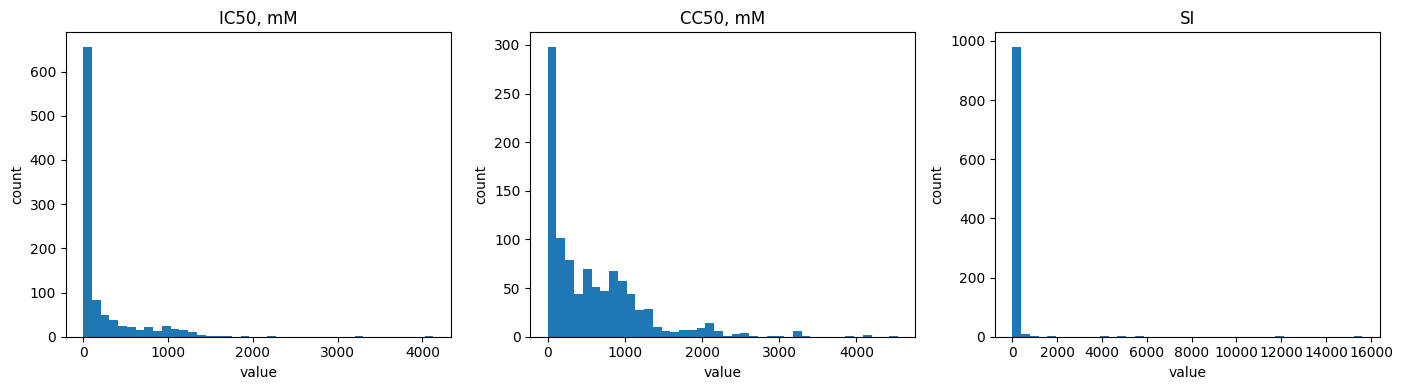

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for axis, column in zip(axes, target_columns):
    axis.hist(data[column], bins=40)
    axis.set_title(column)
    axis.set_xlabel('value')
    axis.set_ylabel('count')
fig.tight_layout()
fig.savefig(ATTACHMENTS_DIR / 'target_histograms.png', dpi=150)
plt.show()


Распределения скошены вправо. Для регрессии это важный признак: модели обучались на `log1p(target)`, чтобы уменьшить влияние крупных значений.

## Проверка связи SI с IC50 и CC50

In [9]:
si_diff = (data['CC50, mM'] / data['IC50, mM'] - data['SI']).abs()
si_diff.describe()

count    1.001000e+03
mean     9.032310e-15
std      9.159952e-14
min      0.000000e+00
25%      0.000000e+00
50%      4.440892e-16
75%      1.776357e-15
max      1.818989e-12
dtype: float64

`SI` практически полностью совпадает с отношением `CC50 / IC50`. Поэтому при построении моделей эти целевые колонки не использовались как признаки. Иначе в задаче появилась бы утечка целевой информации.

## Выбросы

In [10]:
def iqr_outlier_count(series: pd.Series) -> int:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum())

outliers = pd.DataFrame({
    'target': target_columns,
    'iqr_outliers': [iqr_outlier_count(data[column]) for column in target_columns],
})
outliers

,target,iqr_outliers
0,"IC50, mM",147
1,"CC50, mM",39
2,SI,125


Выбросы не удалялись автоматически. Для биологических показателей крупные значения могут быть содержательными, а не ошибочными.

## Корреляции признаков с целями

In [11]:
correlations = data[feature_columns + target_columns].corr(numeric_only=True)[target_columns]
correlations.abs().sort_values('IC50, mM', ascending=False).head(10)

,"IC50, mM","CC50, mM",SI
"IC50, mM",1.000000,0.521346,0.056604
"CC50, mM",0.521346,1.000000,0.006818
VSA_EState4,0.274203,0.190870,0.087837
Chi2n,0.257058,0.254055,0.040949
PEOE_VSA7,0.255988,0.252945,0.036405
Chi2v,0.249164,0.269558,0.048199
fr_Nhpyrrole,0.245511,0.160234,0.016968
fr_Ar_NH,0.245511,0.160234,0.016968
Chi4v,0.243600,0.251166,0.060698
Chi4n,0.243497,0.230276,0.053620


In [12]:
correlations.abs().sort_values('CC50, mM', ascending=False).head(10)

,"IC50, mM","CC50, mM",SI
"CC50, mM",0.521346,1.000000,0.006818
"IC50, mM",1.000000,0.521346,0.056604
MolMR,0.215792,0.310111,0.038233
LabuteASA,0.186695,0.309191,0.039353
MolWt,0.161218,0.306439,0.040156
ExactMolWt,0.161132,0.306382,0.040121
HeavyAtomCount,0.167852,0.305169,0.040842
Chi0,0.167640,0.304792,0.030026
Chi1,0.166475,0.304380,0.042879
HeavyAtomMolWt,0.145234,0.303163,0.044062


In [13]:
correlations.abs().sort_values('SI', ascending=False).head(10)

,"IC50, mM","CC50, mM",SI
SI,0.056604,0.006818,1.000000
BalabanJ,0.196842,0.189650,0.162955
fr_NH2,0.151699,0.150767,0.160470
RingCount,0.154305,0.253273,0.124444
fr_Al_COO,0.049499,0.101459,0.102414
fr_COO2,0.038873,0.096685,0.101115
fr_COO,0.038873,0.096685,0.101115
NumAromaticRings,0.011623,0.172691,0.088064
VSA_EState4,0.274203,0.190870,0.087837
FpDensityMorgan1,0.208710,0.293989,0.087341


Линейные корреляции умеренные. Это объясняет, почему для IC50 и CC50 лучше работают ансамбли деревьев, а линейная модель даёт более слабое качество.

## Итоги EDA

- Данные состоят из 1001 строки и 214 колонок.
- После исключения индекса и целевых полей используется 210 числовых признаков.
- Дубликатов нет.
- Пропуски есть только в 3 строках и нескольких дескрипторах.
- Распределения целей сильно скошены вправо.
- `SI` является отношением `CC50 / IC50`, поэтому при моделировании важно избегать утечки.
- Для моделей используются заполнение пропусков медианой и сравнение нескольких алгоритмов.